In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io  # For loading MATLAB data

def color_region(region_mask, color):
    """
    根据二进制掩码生成彩色区域图像。
    """
    colored_region_mask = np.zeros((*region_mask.shape, 3))
    
    # 设置颜色通道
    if color == 'red':
        colored_region_mask[..., 0] = region_mask  # Red channel
    elif color == 'green':
        colored_region_mask[..., 1] = region_mask  # Green channel
    elif color == 'blue':
        colored_region_mask[..., 2] = region_mask  # Blue channel
    elif color == 'yellow':
        colored_region_mask[..., 0] = region_mask  # Red channel for yellow
        colored_region_mask[..., 1] = region_mask  # Green channel for yellow   
    return colored_region_mask

def combine_layers(inner_set, middle_set, outer_set, colors):
    """
    手动组合每个层的颜色，确保每层都不透明。
    """
    # 创建黑色背景
    combined_image = np.zeros((*inner_set.shape, 3))
    
    # 按顺序叠加 outer_set (蓝色)，middle_set (黄色)，inner_set (红色)
    combined_image = np.where(outer_set[..., None], color_region(outer_set, colors[0]), combined_image)
    combined_image = np.where(middle_set[..., None], color_region(middle_set, colors[1]), combined_image)
    combined_image = np.where(inner_set[..., None], color_region(inner_set, colors[2]), combined_image)
    
    return combined_image

def crplot(inner_set, outer_set, middle_set, color_scheme=None, background=None):
    """
    绘制具有不同置信区间的区域，确保每一层都是不透明的。
    """
    if background is None:
        background = np.zeros((inner_set.shape[0], inner_set.shape[1], 3))  # 黑色背景
    
    # 默认颜色方案，确保 outer_set 是蓝色
    if color_scheme is None:
        color_scheme = ['blue', 'yellow', 'red']  # outer_set 为蓝色
    
    # 生成合并后的图像
    combined_image = combine_layers(inner_set, middle_set, outer_set, color_scheme)
    
    # 显示最终合成的图像
    plt.imshow(background)
    plt.imshow(combined_image, alpha=1.0)  # 完全不透明显示
    plt.axis('off')

In [22]:
def CI_fwer(scores, masks, alpha=0.05):
    """
    Calculate the threshold for family-wise error rate (FWER) in conformal inference.
    Parameters:
    scores (ndarray): 3D array of statistical scores where the last dimension represents different images.
    masks (ndarray): 3D binary array indicating the mask for each image, matching the scores array.
    alpha (float): Significance level for FWER.
    Returns:
    tuple: threshold for FWER, array of maximum values per image after masking.
    """
    nimages = scores.shape[-1]
    max_vals = np.zeros(nimages) # max_vals 用来存储每个样本在非掩码区域的最大分数。

    for i in range(nimages):
        # masked_image = scores[..., i] * (1 - masks[..., i].astype(float)) # 原始代码有问题,可能是python不能兼容的原因
        masked_image = np.nan_to_num(scores[..., i] * (1 - masks[..., i].astype(float)), nan=0.0, posinf=0.0, neginf=0.0)
        #这种方式将 NaN 和极端值（inf 和 -inf）替换为 0，从而避免了绘图或计算过程中出现问题。
        max_vals[i] = masked_image.max()
        print(max_vals[i])
    threshold = np.percentile(max_vals, 100 * (1 - alpha))  
    
    # 绘制 max_vals 的分布和阈值
    plt.figure(figsize=(10, 6))
    plt.hist(max_vals, bins=30, color='skyblue', edgecolor='black', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'{(1 - alpha) * 100}% Threshold: {threshold:.2f}')
    plt.xlabel('Max values')
    plt.ylabel('Density')
    plt.title(f'Distribution of Maximum Values (Threshold at {100 * (1 - alpha)}th percentile)')
    plt.legend()
    plt.show()
    
    return threshold, max_vals



In [23]:
import numpy as np
import scipy.io

# 加载数据
data_path = './resized_data/'
gt_masks_resized = scipy.io.loadmat(data_path + 'gt_masks.mat')['gt_masks_resized']
print(gt_masks_resized.shape)
# print(gt_masks_resized)
bb_masks_resized = scipy.io.loadmat(data_path + 'gt_masks_bb.mat')['bb_masks_resized']
scores_resized = scipy.io.loadmat(data_path + 'scores.mat')['scores_resized']
print(scores_resized.shape)
# print(scores_resized)
scores_BB_inner_resized = scipy.io.loadmat(data_path + 'scores_BB.mat')['scores_BB_inner_resized']
scores_BB_outer_resized = scipy.io.loadmat(data_path + 'scores_BB.mat')['scores_BB_outer_resized']
scores_DT_resized = scipy.io.loadmat(data_path + 'scores_DT.mat')['scores_DT_resized']
learning_idx = scipy.io.loadmat(data_path + 'learning_idx.mat')['learning_idx'].flatten()

# # 获取校准和验证数据集的索引
# non_learning_idx = np.setdiff1d(np.arange(1, 1798), learning_idx) - 1  # 找到除了学习样本之前的样本索引
# val_sample = non_learning_idx[:15]  # 仅用前15个样本用于校准
# cal_sample = np.setdiff1d(non_learning_idx, val_sample) # 最后剩下的用于校准集
# cal_idx = cal_sample
# val_idx = val_sample[:15]  # 仅用前15个样本展示

# %% Obtain indices for the calibration and validation datasets
non_learning_idx = np.setdiff1d(np.arange(1, 1799), learning_idx) - 1
cal_sample = np.random.choice(non_learning_idx, 1000, replace=False) # 1000个校准集
val_sample = np.setdiff1d(non_learning_idx, cal_sample) # 剩余的500个
cal_idx = cal_sample
val_idx = val_sample[:15]  # 仅使用前15个样本进行绘图

print(cal_idx.shape)
# 提取校准集的score数据
cal_scores = scores_resized[:, :, cal_idx]
cal_scores_DT = scores_DT_resized[:, :, cal_idx]
cal_scores_BB_inner = scores_BB_inner_resized[:, :, cal_idx]
cal_scores_BB_outer = scores_BB_outer_resized[:, :, cal_idx]
cal_gt_masks = gt_masks_resized[:, :, cal_idx]

(50, 50, 1798)
(50, 50, 1798)
(1000,)


0.4885771572589874
0.5191218256950378
0.8250970244407654
0.5382506251335144
0.5646994709968567
0.34242966771125793
0.5728874802589417
0.5959225296974182
0.6038911938667297
0.5431334972381592
0.5082283020019531
0.5588967800140381
0.7388061881065369
0.5613605380058289
0.7069208025932312
0.5525562167167664
0.5634167790412903
0.593037486076355
0.5911800861358643
0.5355958938598633
0.6196967363357544
0.6487307548522949
0.5320347547531128
0.5743404626846313
0.5188259482383728
0.6936323642730713
0.6986639499664307
0.582138180732727
0.5988448858261108
0.5431908965110779
0.5802554488182068
0.635638415813446
0.3334791958332062
0.603524923324585
0.5966805815696716
0.5418118834495544
0.582915186882019
0.5860931277275085
0.5201048851013184
0.3125717341899872
0.5516827702522278
0.5403117537498474
0.6296166181564331
0.5670938491821289
0.31257420778274536
0.6129562854766846
0.5325430035591125
0.2871745526790619
0.5588967800140381
0.6982582211494446
0.5625991225242615
0.6760134100914001
0.5205316543579

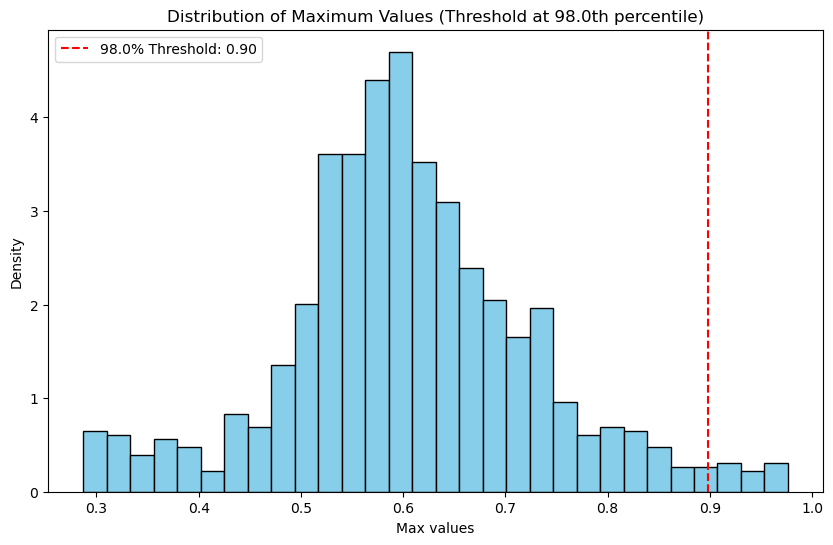

1.0
2.0
8.9442720413208
3.1622776985168457
1.0
-0.0
2.8284270763397217
72.20111083984375
1.0
5.830951690673828
1.0
6.4031243324279785
2.2360680103302
1.0
2.8284270763397217
2.0
1.4142135381698608
0.0
1.4142135381698608
4.0
1.0
2.0
3.605551242828369
0.0
135.53228759765625
1.0
1.4142135381698608
2.0
134.40609741210938
2.0
8.062257766723633
1.0
-0.0
2.2360680103302
2.2360680103302
5.830951690673828
5.099019527435303
1.0
1.0
-0.0
3.0
1.0
3.1622776985168457
6.0
-0.0
63.812225341796875
2.8284270763397217
-0.0
6.4031243324279785
1.4142135381698608
1.0
0.0
2.2360680103302
1.0
3.605551242828369
9.848857879638672
1.0
2.2360680103302
1.4142135381698608
2.0
4.242640495300293
8.9442720413208
4.242640495300293
2.2360680103302
1.0
1.0
17.0
1.0
4.0
8.9442720413208
62.2414665222168
2.0
1.0
50.28916549682617
1.0
1.4142135381698608
3.0
-0.0
20.099750518798828
2.8284270763397217
4.242640495300293
2.0
2.0
7.211102485656738
1.0
3.1622776985168457
6.7082037925720215
2.2360680103302
1.4142135381698608
29.0
1.

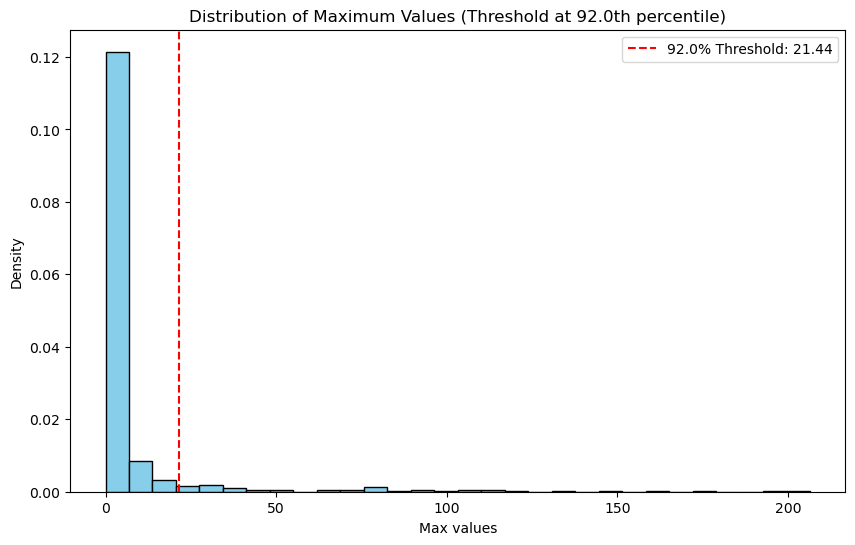

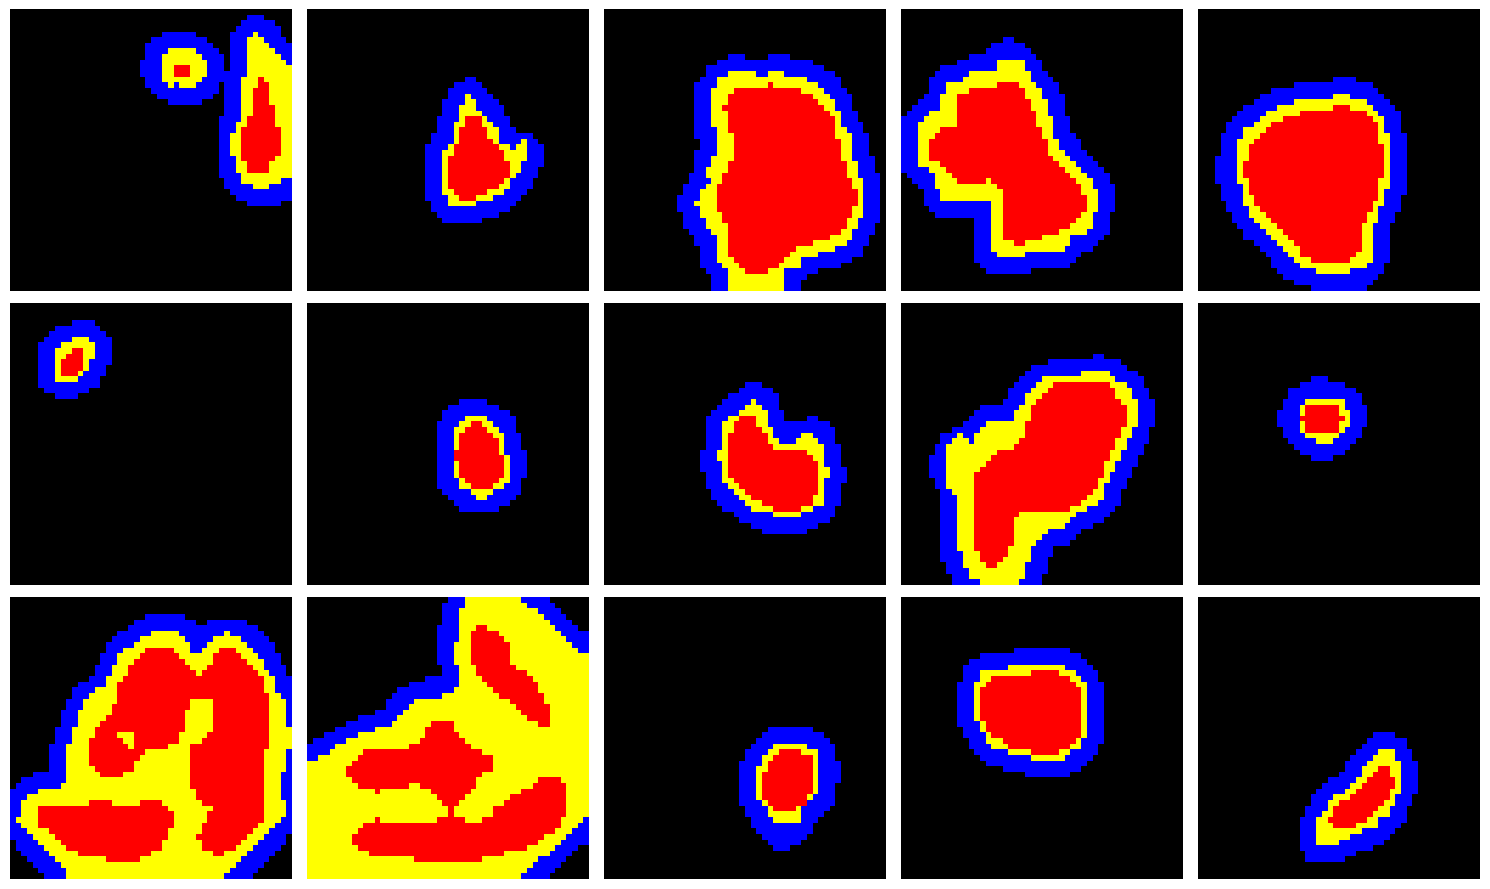

0.0
-0.0
37.0
-0.0
-0.0
0.0
-0.0
0.0
-0.0
0.0
-0.0
-0.0
3.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
2.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
1.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
22.0
-0.0
-0.0
-0.0
1.0
-0.0
15.0
0.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
6.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
2.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
1.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
17.0
1.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
0.0
0.0
-0.0
-0.0
-0.0
3.0
-0.0
-0.0
0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-0.0
9.0
-0.0
9.0
-0.0
-0.0
-0.0
36.0
-0.0
-0.0
47.0
0.0
-0.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
1.0
-0.0
-0.0
7.0
1.0
-0.0
-0.0
7.0
-0.0
-0.0
-0.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
2.0
-0.0
23.0
-0.0
2.0
-0.0
-0.0
-0.0
-0.0
-0.0
3.0
-0.0
-0.0
8.0
5.0
-0.0
-0.0
0.0
-0.0
-0.0
-0.0
-

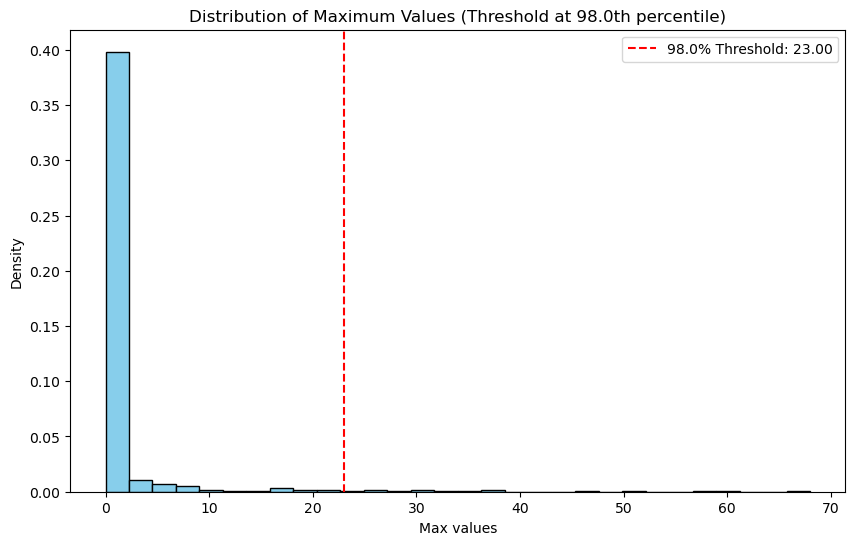

0.0
0.0
6.0
3.0
0.0
0.0
1.0
58.0
0.0
2.0
0.0
3.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
0.0
0.0
2.0
0.0
129.0
0.0
0.0
1.0
125.0
0.0
1.0
0.0
0.0
0.0
0.0
5.0
5.0
0.0
1.0
0.0
2.0
0.0
3.0
6.0
0.0
7.0
0.0
0.0
3.0
0.0
0.0
0.0
0.0
1.0
0.0
7.0
1.0
0.0
0.0
0.0
1.0
0.0
2.0
0.0
0.0
1.0
13.0
0.0
3.0
0.0
41.0
0.0
0.0
38.0
0.0
1.0
0.0
0.0
20.0
0.0
0.0
0.0
0.0
3.0
1.0
0.0
0.0
1.0
0.0
17.0
0.0
0.0
2.0
0.0
1.0
2.0
1.0
0.0
0.0
0.0
0.0
27.0
0.0
0.0
0.0
0.0
1.0
2.0
1.0
3.0
1.0
0.0
0.0
0.0
0.0
16.0
0.0
11.0
0.0
0.0
0.0
0.0
0.0
0.0
3.0
6.0
2.0
37.0
0.0
1.0
0.0
0.0
5.0
0.0
0.0
17.0
0.0
0.0
3.0
89.0
0.0
0.0
1.0
0.0
1.0
3.0
0.0
0.0
0.0
0.0
0.0
0.0
10.0
1.0
0.0
3.0
3.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
23.0
2.0
2.0
0.0
2.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
0.0
1.0
0.0
0.0
0.0
2.0
0.0
0.0
0.0
0.0
0.0
1.0
9.0
0.0
3.0
0.0
4.0
0.0
0.0
0.0
1.0
14.0
1.0
-0.0
0.0
0.0
0.0
2.0
0.0
0.0
1.0
7.0
70.0
5.0
37.0
0.0
0.0
195.0
1.0
2.0
0.0
0.0
2.0
0.0
0.0
6.0
1.0
3.0
-0.0
0.0
3.0
0.0
0.0
0.0
0.0
9.0
0.0
60.0
1.0
1.0
0.0
1.0
0.0
0.0
0.0
0.0
1.

/tmp/ipykernel_73930/2858279521.py:16: RuntimeWarning: invalid value encountered in multiply
  masked_image = np.nan_to_num(scores[..., i] * (1 - masks[..., i].astype(float)), nan=0.0, posinf=0.0, neginf=0.0)


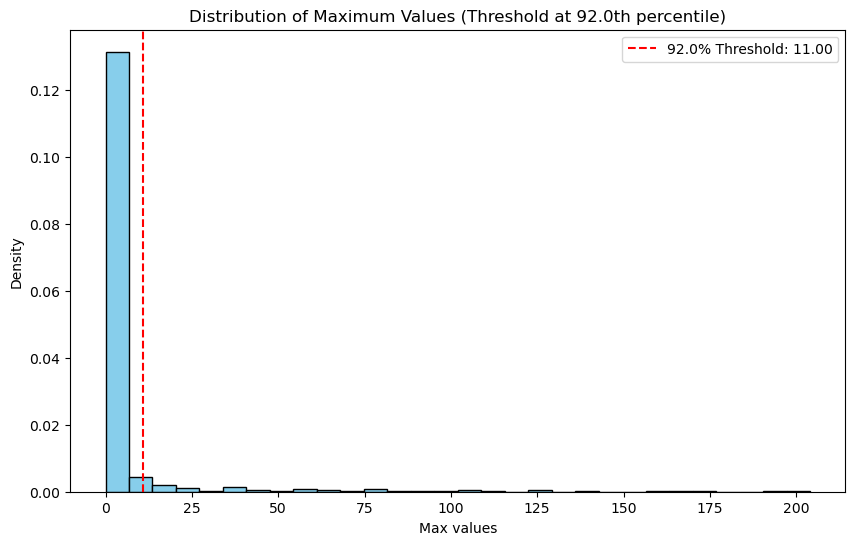

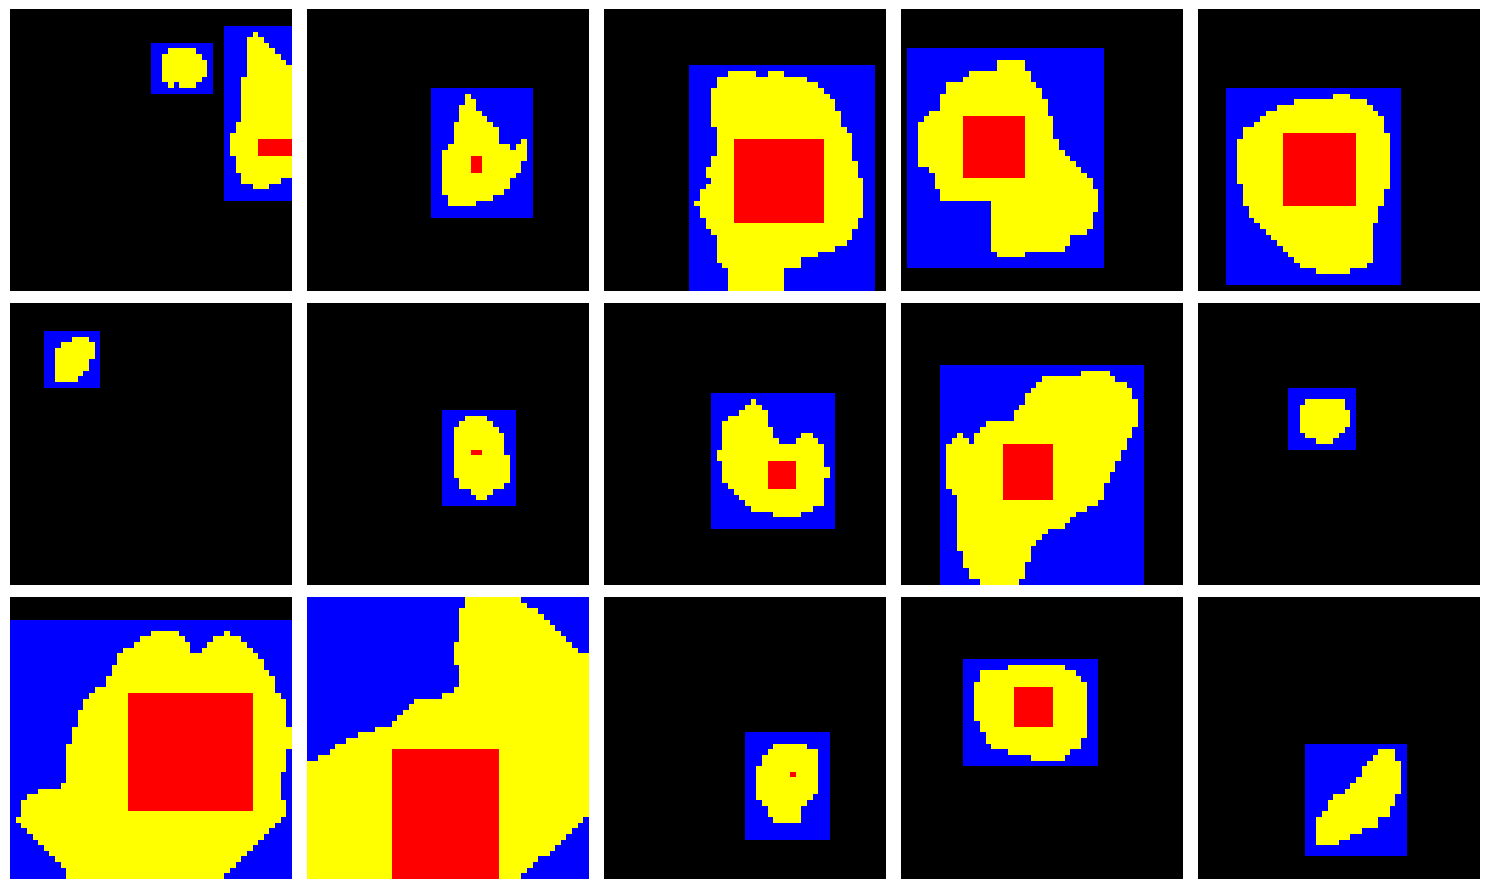

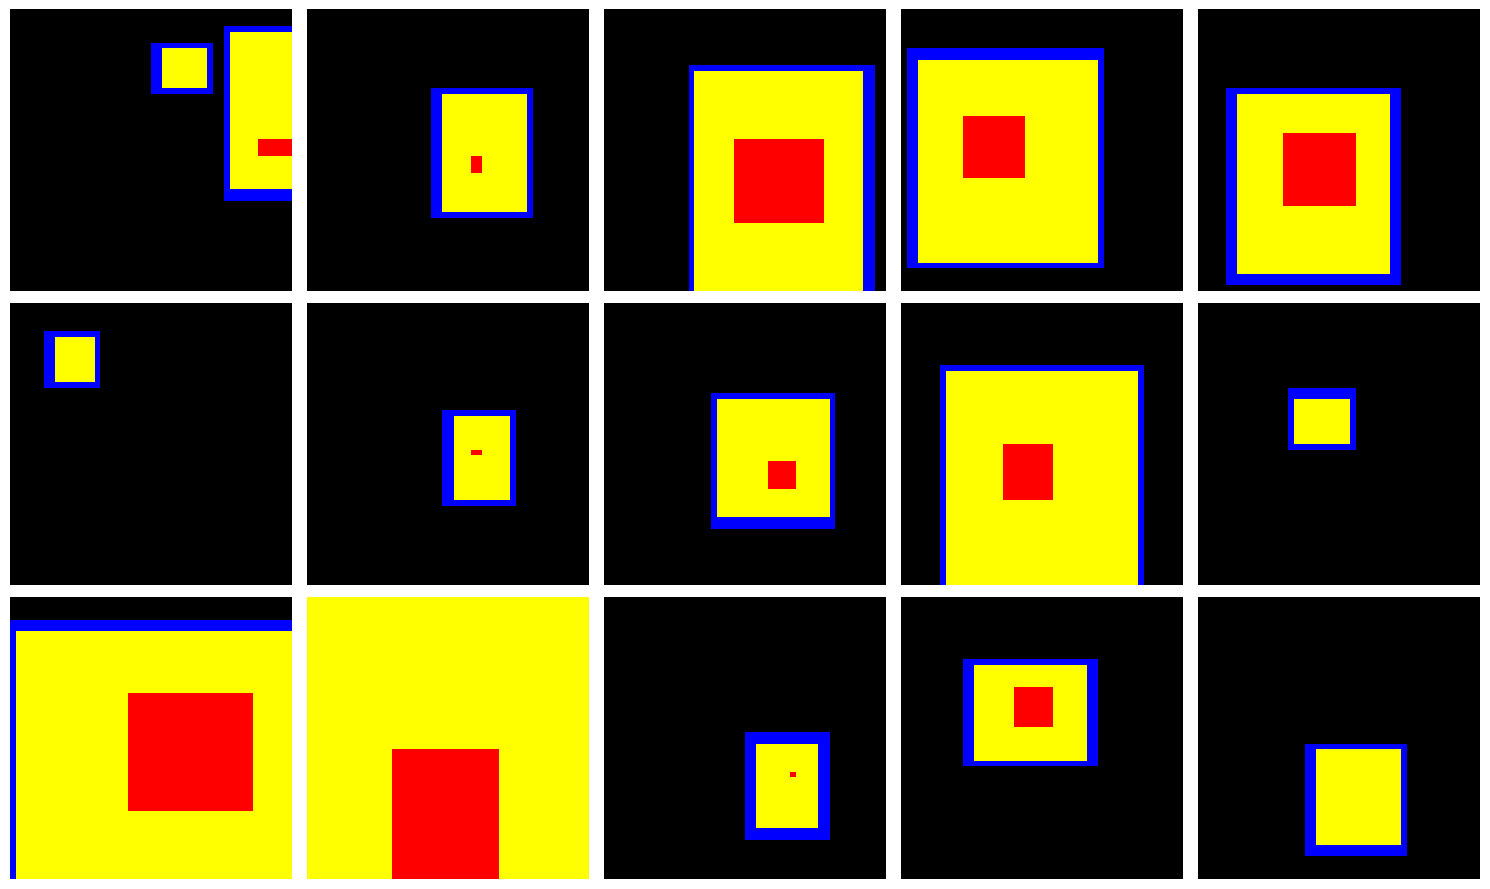

In [24]:
alpha1 = 0.02
alpha2 = 0.08

# alpha1 = 0.05
# alpha2 = 0.05

# alpha1 = 0.02
# alpha2 = 0.02

# 计算内外置信阈值
threshold_inner, _ = CI_fwer(cal_scores, cal_gt_masks, alpha1)
threshold_outer, _ = CI_fwer(-cal_scores_DT, 1 - cal_gt_masks, alpha2)
# 创建3x5网格用于显示图像
fig, axs = plt.subplots(3, 5, figsize=(15, 9))
for i, ex in enumerate(val_idx):
    # 提取当前示例的分数图和掩码
    score_im = scores_resized[:, :, ex]
    score_im_DT = scores_DT_resized[:, :, ex]
    mask = gt_masks_resized[:, :, ex]

    # 生成内层和外层的二值掩码
    predicted_inner = score_im > threshold_inner  # 内层区域掩码
    predicted_outer = (-score22_im_DT) < threshold_outer  # 外层区域掩码，增加反相处理

    # 在当前子图上使用 crplot 函数绘制区域
    ax = axs.flat[i]
    plt.sca(ax)  # 设置当前子图为活动子图
    crplot(predicted_inner, predicted_outer, mask)  # 绘制 outer, middle, inner
    
plt.tight_layout()
plt.show()


# 计算边界框分数的置信阈值
threshold_inner_bb, _ = CI_fwer(cal_scores_BB_inner, cal_gt_masks, alpha1)

threshold_outer_bb, max_vals = CI_fwer(-cal_scores_BB_outer, 1 - cal_gt_masks, alpha2)  # 与MATLAB保持一致的显著性水平
# 绘制边界框的置信集
for j in range(2):
    fig, axs = plt.subplots(3, 5, figsize=(15, 9))
    for i, ex in enumerate(val_idx[:15]):  # 确保取前15个示例
        # 提取当前示例的边界框分数图和掩码
        score_im_inner = scores_BB_inner_resized[:, :, ex]
        score_im_outer = scores_BB_outer_resized[:, :, ex]
        mask = gt_masks_resized[:, :, ex] if j == 0 else bb_masks_resized[:, :, ex]

        # 生成内层和外层的二值掩码
        predicted_inner = score_im_inner > threshold_inner_bb  # 内层区域
        predicted_outer = (-score_im_outer) < threshold_outer_bb  # 外层区域，反相处理

        # 使用 crplot 函数在当前子图上绘制区域
        ax = axs.flat[i]
        plt.sca(ax)  # 设置当前子图为活动子图
        crplot(predicted_inner, predicted_outer, mask)  # 按顺序绘制 outer, middle, inner
        
        ax.axis('off')  # 关闭坐标轴
    plt.tight_layout()
    plt.show()